In [3]:
import glob,pickle
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [4]:
tas = xr.open_dataarray('/work/bb1445/b383514/other/train_disruption/eobs/city_temperature.nc')

In [5]:
tas

<xarray.DataArray 'tg' (city: 10, time: 27759)>
[277590 values with dtype=float32]
Coordinates:
    longitude  (city) float64 ...
    latitude   (city) float64 ...
  * time       (time) datetime64[ns] 1950-01-01 1950-01-02 ... 2025-12-31
  * city       (city) object 'Hamburg Hbf' 'Nürnberg Hbf' ... 'Essen Hbf'
Attributes:
    units:          Celsius
    long_name:      mean temperature
    standard_name:  air_temperature

In [ ]:
delays = pd.read_parquet('/work/bb1445/b383514/other/train_disruption/train_data_complete/2021/2021-09-01.parquet')

In [20]:
stops = pd.read_parquet('/work/bb1445/b383514/other/train_disruption/train_data_complete/stops.parquet')

In [41]:
data = {}
for station in tas.city.values:
    l_days = []
    for file in sorted(glob.glob('/work/bb1445/b383514/other/train_disruption/train_data_complete/202*/202*-*')):
        if int(file.split('/')[-1].split('-')[1]) in [5,6,7,8,9]:
            delays = pd.read_parquet(file)
            try:
                stop_ids = stops.loc[stops.stop_name == station].stop_id
                l = []
                for stop_id in stop_ids:
                    l.append(delays.loc[delays.stop_id == stop_id])
                data_at_station = pd.concat(l)
            except:
                # needed for Frankfurt(Main)Hbf ?!?!
                station_ = station.replace(' ','')
                stop_ids = stops.loc[stops.stop_name == station_].stop_id
                for stop_id in stop_ids:
                    l.append(delays.loc[delays.stop_id == stop_id])
                data_at_station = pd.concat(l)
    
    
            date = str(data_at_station.time_schedule.values[0])[:10]
            l_days.append(
                dict(
                    tas = float(tas.loc[station, date]),
                    mean_delay = data_at_station.delay.mean(),
                    delaid_frac = np.nansum(data_at_station.delay > 0) / np.sum(np.isfinite(data_at_station.delay)),
                    canceled_frac = np.nansum(data_at_station.is_cancelled) / np.sum(np.isfinite(data_at_station.delay)),  
                )
            )
    data[station] = pd.DataFrame(l_days)


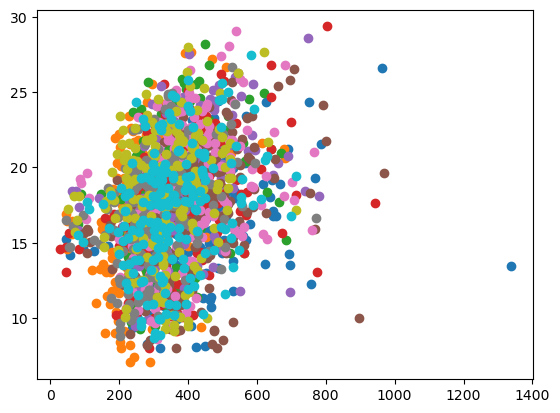

In [42]:
for station,d in data.items():
    plt.scatter(d.mean_delay, d.tas)

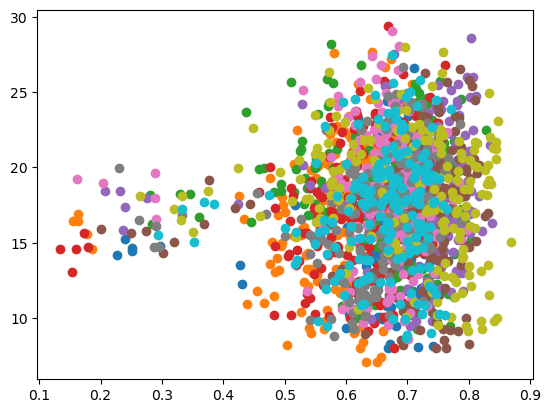

In [45]:
for station,d in data.items():
    plt.scatter(d.delaid_frac, d.tas)

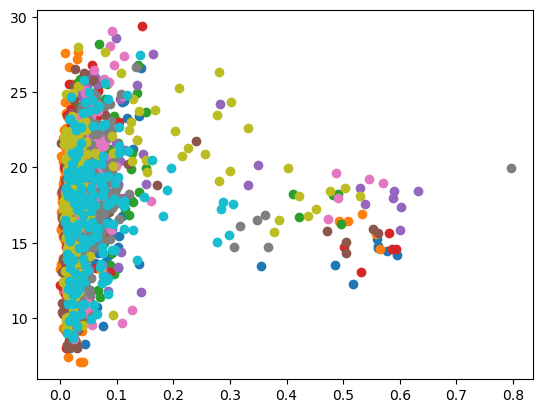

In [46]:
for station,d in data.items():
    plt.scatter(d.canceled_frac, d.tas)

In [44]:
for station,d in data.items():
    d.to_csv(f'{station}.csv')

### Do plots with tx, tn and tg

In [1]:
import glob,pickle
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
t = xr.open_dataset('/work/bb1445/b383514/other/train_disruption/eobs/city_tg_tn_tx.nc')

In [3]:
tn = t.tn
tx = t.tx
tg = t.tg

In [4]:
tg.longitude["city"=="Hamburg Hbf"].compute()

<xarray.DataArray 'longitude' ()>
array(9.875)
Coordinates:
    longitude  float64 9.875
    latitude   float64 53.62
    city       <U11 'Hamburg Hbf'
Attributes:
    units:          degrees_east
    long_name:      Longitude values
    axis:           X
    standard_name:  longitude

In [5]:
t

<xarray.Dataset>
Dimensions:    (city: 10, time: 27759)
Coordinates:
    longitude  (city) float64 ...
    latitude   (city) float64 ...
  * time       (time) datetime64[ns] 1950-01-01 1950-01-02 ... 2025-12-31
  * city       (city) object 'Hamburg Hbf' 'Berlin Hbf' ... 'Essen Hbf'
Data variables:
    tn         (time, city) float32 ...
    tx         (time, city) float32 ...
    tg         (time, city) float32 ...

In [6]:
delays = pd.read_parquet('/work/bb1445/b383514/other/train_disruption/train_data_complete/2021/2021-09-01.parquet')

In [7]:
delays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1110172 entries, 0 to 1110171
Data columns (total 28 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   platform_id_schedule         1110172 non-null  int64         
 1   stop_sequence                1110172 non-null  uint16        
 2   time_schedule                1110172 non-null  datetime64[us]
 3   distance_traveled            1110172 non-null  int32         
 4   trip_id                      1110172 non-null  int64         
 5   trip_headsign                1110172 non-null  int64         
 6   update_timestamp             1044450 non-null  datetime64[us]
 7   platform_id_real             1110172 non-null  int64         
 8   time_real                    1110172 non-null  datetime64[us]
 9   is_cancelled                 1110172 non-null  bool          
 10  message_codes                225758 non-null   object        
 11  is_betriebs

In [8]:
stops = pd.read_parquet('/work/bb1445/b383514/other/train_disruption/train_data_complete/stops.parquet')

In [9]:
stops

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code
0,8000014,Aulendorf,47.953052,9.644046,STATION,NaN,None
1,111502,"Stierstadt Bahnhof, Oberursel (Taunus)",50.185995,8.584986,STATION,NaN,None
2,1132323441011781673,"Stierstadt Bahnhof, Oberursel (Taunus)",50.185995,8.584986,STOP,111502.0,
3,8618964833743409459,Schladming,47.393825,13.678151,STOP,8100137.0,3
4,3518787262705436720,Holedecek,50.284985,13.558695,STOP,5453327.0,
...,...,...,...,...,...,...,...
41366,102705,"Bahnhof, Langen (Hessen)",49.993458,8.657656,STATION,NaN,None
41367,3252429004821121703,"Bahnhof, Langen (Hessen)",49.993458,8.657656,STOP,102705.0,2
41368,522801,"Großhelfendorf (S), Aying",47.944524,11.782579,STATION,NaN,None
41369,-5826719480316094792,"Großhelfendorf (S), Aying",47.944524,11.782579,STOP,522801.0,


In [28]:
berlin = stops[stops.stop_name.str.contains('Frankfurt', case=False, na=False)]
berlin

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code
22,-5147101607580409906,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,9
93,4151436960411591555,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,1
128,785757424655312773,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,2
263,8000105,Frankfurt(Main)Hbf,50.107145,8.663789,STATION,NaN,None
292,6472402301114668347,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,18
...,...,...,...,...,...,...,...
41064,101201,Frankfurt(Main) Falkstraße/Bockenheimer Warte,50.119984,8.652408,STATION,NaN,None
41070,2522319657610694268,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,14 D-F
41071,3079648631733025508,Frankfurt(Main)Hbf,50.107145,8.663789,STOP,8000105.0,14 A-C
41292,-849790517356866451,Frankfurt(M) Flughafen Fernbahnhof (Squaire),50.053120,8.569550,STOP,8089361.0,


In [11]:
# df    = your 1.12M-row dataframe
# stops = the stop_id dataset

# 1. Make sure stop_id is unique in the lookup table
print(stops["stop_id"].duplicated().sum())   # should be 0

# 2. Make sure both keys have the same dtype
stops["stop_id"] = stops["stop_id"].astype("int64")

# 3. Merge with an indicator to track failed matches
df = delays.merge(
    stops[["stop_id", "stop_name"]],
    on="stop_id",
    how="left",
    validate="m:1",        # raises an error if stop_id is not unique in stops
    indicator=True,
).copy()

# 4. Count the rows without a match
n_unmatched_rows = (df["_merge"] == "left_only").sum()
n_unmatched_ids = df.loc[df["_merge"] == "left_only", "stop_id"].nunique()

print(f"Rows without a match:      {n_unmatched_rows} of {len(df)}")
print(f"Distinct unmatched stop_ids: {n_unmatched_ids}")

df = df.drop(columns="_merge")

0
Rows without a match:      0 of 1110172
Distinct unmatched stop_ids: 0


In [12]:
df

,platform_id_schedule,stop_sequence,time_schedule,distance_traveled,trip_id,trip_headsign,update_timestamp,platform_id_real,time_real,is_cancelled,...,line,is_regional,is_final,dwell_time_schedule,dwell_time_real,is_arrival,initial_scheduled_departure,initial_stop_id,delay,stop_name
0,9029754901402710705,1,2021-09-01 02:41:00,0,-9223238485602530826,8006076,2021-09-01 02:42:00,9029754901402710705,2021-09-01 02:42:00,False,...,RS1,True,True,NaN,NaN,False,2021-09-01 02:41:00,8007898.0,60,Bremen-Farge
1,3700486743782014366,2,2021-09-01 02:43:00,3679,-9223238485602530826,8006076,2021-09-01 02:46:00,3700486743782014366,2021-09-01 02:43:00,False,...,RS1,True,True,120.0,180.0,True,2021-09-01 02:41:00,8007898.0,0,Bremen Turnerstraße
2,3700486743782014366,2,2021-09-01 02:45:00,3679,-9223238485602530826,8006076,2021-09-01 02:46:00,3700486743782014366,2021-09-01 02:46:00,False,...,RS1,True,True,120.0,180.0,False,2021-09-01 02:41:00,8007898.0,60,Bremen Turnerstraße
3,-5612385967600266428,3,2021-09-01 02:47:00,5118,-9223238485602530826,8006076,2021-09-01 02:47:00,-5612385967600266428,2021-09-01 02:47:00,False,...,RS1,True,True,0.0,0.0,True,2021-09-01 02:41:00,8007898.0,0,Bremen Kreinsloger
4,-5612385967600266428,3,2021-09-01 02:47:00,5118,-9223238485602530826,8006076,2021-09-01 02:47:00,-5612385967600266428,2021-09-01 02:47:00,False,...,RS1,True,True,0.0,0.0,False,2021-09-01 02:41:00,8007898.0,0,Bremen Kreinsloger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1110167,-780845502717330817,17,2021-09-01 07:35:00,144444,9223054868868978686,8000056,2021-09-01 07:37:00,-780845502717330817,2021-09-01 07:37:00,False,...,RB38,True,True,60.0,0.0,True,2021-09-01 05:51:00,8000152.0,120,Holm-Seppensen
1110168,-780845502717330817,17,2021-09-01 07:36:00,144444,9223054868868978686,8000056,2021-09-01 07:37:00,-780845502717330817,2021-09-01 07:37:00,False,...,RB38,True,True,60.0,0.0,False,2021-09-01 05:51:00,8000152.0,60,Holm-Seppensen
1110169,-725662361685712633,18,2021-09-01 07:39:00,148411,9223054868868978686,8000056,2021-09-01 07:42:00,-725662361685712633,2021-09-01 07:41:00,False,...,RB38,True,True,60.0,60.0,True,2021-09-01 05:51:00,8000152.0,120,Suerhop
1110170,-725662361685712633,18,2021-09-01 07:40:00,148411,9223054868868978686,8000056,2021-09-01 07:42:00,-725662361685712633,2021-09-01 07:42:00,False,...,RB38,True,True,60.0,60.0,False,2021-09-01 05:51:00,8000152.0,120,Suerhop


In [29]:
ds = t

new_cities = [
    "Frankfurt(Main)Hbf" if c == "Frankfurt Hbf" else c
    for c in ds["city"].values
]
ds = ds.assign_coords(city=new_cities)

cities = list(ds["city"].values)
cities

['Hamburg Hbf',
 'Berlin Hbf',
 'Düsseldorf Hbf',
 'Hannover Hbf',
 'Köln Hbf',
 'München Hbf',
 'Frankfurt(Main)Hbf',
 'Dortmund Hbf',
 'Stuttgart Hbf',
 'Essen Hbf']

In [18]:
city_stops = stops.loc[stops["stop_name"].isin(cities), ["stop_id", "stop_name"]]
city_stops

,stop_id,stop_name
1200,-2717051510988322483,Essen Hbf
1204,-6945063533250578574,Dortmund Hbf
1227,6300272415810523029,Köln Hbf
1330,-4845201591013426544,Hamburg Hbf
1358,-8064645504252351884,Hamburg Hbf
...,...,...
37451,-5638883582698173020,Berlin Hbf
37872,2435379051585938017,Hannover Hbf
37873,-8809192267825665605,Hannover Hbf
37910,3479745538160280321,Köln Hbf


In [19]:
set(cities)

{'Berlin Hbf',
 'Dortmund Hbf',
 'Düsseldorf Hbf',
 'Essen Hbf',
 'Frankfurt Hbf',
 'Hamburg Hbf',
 'Hannover Hbf',
 'Köln Hbf',
 'München Hbf',
 'Stuttgart Hbf'}

In [30]:
import glob
from pathlib import Path
import pandas as pd

ds = t

# ---- settings ----
pattern = "/work/bb1445/b383514/other/train_disruption/train_data_complete/202*/202*-*"
out_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")
out_dir.mkdir(parents=True, exist_ok=True)

MONTHS = [5, 6, 7, 8, 9]
DELAY_THRESHOLD = 0          # in the unit of 'delay' (6 min; use 360 if seconds; 0 = any delay)
cols = ["stop_id", "time_schedule", "is_cancelled", "delay"]   # add "is_arrival" if you filter on it
# ------------------

# 1. lookup: only the stop_ids belonging to your cities
new_cities = [
    "Frankfurt(Main)Hbf" if c == "Frankfurt Hbf" else c
    for c in ds["city"].values
]
ds = ds.assign_coords(city=new_cities)
cities = list(ds["city"].values)
city_stops = stops.loc[stops["stop_name"].isin(cities), ["stop_id", "stop_name"]]
city_stops = city_stops.drop_duplicates("stop_id")
stop_to_city = city_stops.set_index("stop_id")["stop_name"]

missing = set(cities) - set(city_stops["stop_name"])
if missing:
    print("Cities not found in the stop table:", missing)

# 2. read all files, keep only the relevant rows
parts = []
for file in sorted(glob.glob(pattern)):
    if int(file.split("/")[-1].split("-")[1]) not in MONTHS:
        continue
    d = pd.read_parquet(file, columns=cols)
    d = d[d["stop_id"].isin(stop_to_city.index)]
    if d.empty:
        continue
    d["stop_name"] = d["stop_id"].map(stop_to_city)
    parts.append(d)
    print(f"{file.split('/')[-1]}: {len(d)} rows kept")

data = pd.concat(parts, ignore_index=True)
data["date"] = pd.to_datetime(data["time_schedule"]).dt.normalize()

def safe_name(name):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in name)

# 3. one CSV per city
for city in cities:
    sub = data[data["stop_name"] == city]
    if sub.empty:
        print(f"{city}: no rows, skipped")
        continue

    not_cancelled = sub[~sub["is_cancelled"]]
    daily = pd.DataFrame({
        "n_trains": sub.groupby("date").size(),
        "fraction_cancelled": sub.groupby("date")["is_cancelled"].mean(),
        "mean_delay": not_cancelled.groupby("date")["delay"].mean(),
        "fraction_delayed": (not_cancelled["delay"] >= DELAY_THRESHOLD)
                            .groupby(not_cancelled["date"]).mean(),
    })

    weather = (
        ds[["tn", "tx", "tg"]].sel(city=city).load().to_dataframe()
        .drop(columns=["city", "longitude", "latitude"], errors="ignore")
    )
    weather.index = pd.to_datetime(weather.index).normalize()
    weather.index.name = "date"

    out = daily.join(weather, how="left").reset_index()
    out.to_csv(out_dir / f"{safe_name(city)}.csv", index=False)
    print(f"{city}: {len(out)} days saved")

2021-09-01.parquet: 13108 rows kept
2021-09-02.parquet: 13100 rows kept
2021-09-03.parquet: 13402 rows kept
2021-09-04.parquet: 11707 rows kept
2021-09-05.parquet: 10611 rows kept
2021-09-06.parquet: 12968 rows kept
2021-09-07.parquet: 13030 rows kept
2021-09-08.parquet: 13050 rows kept
2021-09-09.parquet: 12916 rows kept
2021-09-10.parquet: 13343 rows kept
2021-09-11.parquet: 11908 rows kept
2021-09-12.parquet: 10890 rows kept
2021-09-13.parquet: 13283 rows kept
2021-09-14.parquet: 13195 rows kept
2021-09-15.parquet: 13184 rows kept
2021-09-16.parquet: 13208 rows kept
2021-09-17.parquet: 13530 rows kept
2021-09-18.parquet: 11861 rows kept
2021-09-19.parquet: 11018 rows kept
2021-09-20.parquet: 12794 rows kept
2021-09-21.parquet: 12381 rows kept
2021-09-22.parquet: 12397 rows kept
2021-09-23.parquet: 12419 rows kept
2021-09-24.parquet: 12815 rows kept
2021-09-25.parquet: 11305 rows kept
2021-09-26.parquet: 10576 rows kept
2021-09-27.parquet: 12611 rows kept
2021-09-28.parquet: 12561 ro

In [32]:
from pathlib import Path
import pandas as pd

ds = t

# ---- settings ----
out_dir = Path("/home/b/b383514/other/Train_Disrubtion/data/processed_new")   # change to where you want the files
out_dir.mkdir(parents=True, exist_ok=True)

DELAY_THRESHOLD = 0      # in the unit of the 'delay' column; 6 min is the common DB definition
                         # (use 0 if any delay > 0 should count)
# ------------------

# make sure the date is a plain date
df["date"] = pd.to_datetime(df["time_schedule"]).dt.normalize()

def safe_name(name):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in name)

for city in ds["city"].values:
    # --- 1. train data for this city, aggregated per day ---
    sub = df[df["stop_name"] == city]
    if sub.empty:
        print(f"{city}: no rows in df, skipped")
        continue

    not_cancelled = sub[~sub["is_cancelled"]]

    daily = pd.DataFrame({
        "n_trains": sub.groupby("date").size(),
        "fraction_cancelled": sub.groupby("date")["is_cancelled"].mean(),
        "mean_delay": not_cancelled.groupby("date")["delay"].mean(),
        "fraction_delayed": (not_cancelled["delay"] >= DELAY_THRESHOLD)
                            .groupby(not_cancelled["date"]).mean(),
    })

    # --- 2. weather data for this city ---
    weather = (
        ds[["tn", "tx", "tg"]]
        .sel(city=city)
        .load()
        .to_dataframe()
        .drop(columns=["city", "longitude", "latitude"], errors="ignore")
    )
    weather.index = pd.to_datetime(weather.index).normalize()
    weather.index.name = "date"

    # --- 3. combine (only days with train data) and save ---
    out = daily.join(weather, how="left").reset_index()
    out.to_csv(out_dir / f"{safe_name(city)}.csv", index=False)
    print(f"{city}: {len(out)} days saved")

Hamburg Hbf: 2 days saved
Nürnberg Hbf: 2 days saved
Düsseldorf Hbf: 2 days saved
Hannover Hbf: 2 days saved
Köln Hbf: 2 days saved
München Hbf: 2 days saved
Frankfurt Hbf: no rows in df, skipped
Dortmund Hbf: 2 days saved
Stuttgart Hbf: 2 days saved
Essen Hbf: 2 days saved


In [ ]:
city_locations = {'Hamburg Hbf': (53.55073, 9.99302),
 'Berlin Hbf': (52.52501, 13.36962),
 'Düsseldorf Hbf': (51.22172, 6.77616),
 'Hannover Hbf': (52.37052, 9.73322),
 'Köln Hbf': (50.93333, 6.95),
 'München Hbf': (48.06489, 11.66327),
 'Frankfurt Hbf': (50.11552, 8.68417),
 'Dortmund Hbf': (51.51494, 7.466),
 'Stuttgart Hbf': (48.78232, 9.17702),
 'Essen Hbf': (51.45657, 7.01228)}